* 2025-04-24

Create the LO and NLO RG flow for Sebastian Koenig.

Use the old 2,8,8 regularization scheme that we also employed in the van der Waals paper with Arnas

In [1]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt
import mu2
import scienceplots
from scipy.optimize import fsolve
import helium4plusplusphysical as he4
plt.style.use('science')
gr = 4/3
h = 3

plotsize = 2
plt.rcParams['figure.figsize'] = [1.618*plotsize,plotsize]
plt.rcParams['figure.dpi'] = 200

# LO RG flow 

In [2]:
nLO = 1000

R_MAX = he4.BETA6/2
R_MIN = he4.BETA6/25

R_LO = 2/np.linspace(2/R_MAX, 2/R_MIN, nLO)

gsLO = np.zeros(nLO)
b2sLO = np.zeros(nLO)
r0sLO = np.zeros(nLO)

In [3]:
# momentum grid
momenta = np.linspace(0.01/he4.BETA6, 0.3/he4.BETA6, 70)

ELL = 0

N1 = 2
N2 = 8
NCT = 8

In [4]:
def inverse_a0_diff_lo(g, sys):
    a0, _ = sys.a0_and_r0(g, 0, momenta, use_c=True)
    return (1/he4.A0 - 1/a0)*he4.A0

In [5]:
# scale to render g dimensionless
X = he4.FACTOR * he4.BETA6 # K•Å^3
0.0345*X

2.2481994292847087

In [23]:
R=R_LO[0]
print('R=',R)
s = he4.NonlocalHelium4System(R, ELL, N1, N2, NCT)

R= 2.6884930808114067
Generating matrix elements for l = 0 and lp = 0.


In [24]:
guess = 804.*X
s.a0_and_r0(guess, 0, momenta, use_c=True), s.bound_state_spectrum(guess, 0)

((100.91008126347194, 8.303559953057507), array([-0.00130192]))

In [31]:
for i in range(nLO):
    R = R_LO[i]
    s = he4.NonlocalHelium4System(R, ELL, N1, N2, NCT)
    result = optimize.fsolve(inverse_a0_diff_lo, guess, args=(s), factor=0.1)
    g = result[0]
    a0, r0 = s.a0_and_r0(g, 0, momenta)
    print('a0=',a0)
    if np.abs((he4.A0 - a0)/he4.A0) < 1e-4:
        e2s = s.bound_state_spectrum(g, 0)
        gsLO[i] = g
        r0sLO[i] = r0
        b2sLO[i] = np.abs(e2s[0])
        print(f'i = {i}  R = {R}  g = {g/X:.4e} X  a0 = {a0:.4e}  r0 = {r0:.4e}  b2 = {np.abs(e2s[0])}')
    else:
        break

Generating matrix elements for l = 0 and lp = 0.
a0= 99.9999999784603
i = 0  R = 2.6884930808114067  g = 8.0371e+02 X  a0 = 1.0000e+02  r0 = 8.2998e+00  b2 = 0.0013268068997916496
Generating matrix elements for l = 0 and lp = 0.
a0= 99.9999999388131
i = 1  R = 2.6578966726675852  g = 8.8053e+02 X  a0 = 1.0000e+02  r0 = 8.2525e+00  b2 = 0.0013260236939316114
Generating matrix elements for l = 0 and lp = 0.
a0= 99.99999999646414
i = 2  R = 2.627988833395886  g = 9.7871e+02 X  a0 = 1.0000e+02  r0 = 8.2072e+00  b2 = 0.0013252756822698262
Generating matrix elements for l = 0 and lp = 0.
a0= 99.99999999043956
i = 3  R = 2.598746577388094  g = 1.1112e+03 X  a0 = 1.0000e+02  r0 = 8.1639e+00  b2 = 0.001324561840082604
Generating matrix elements for l = 0 and lp = 0.
a0= 99.9999999981033
i = 4  R = 2.5701479308426745  g = 1.3046e+03 X  a0 = 1.0000e+02  r0 = 8.1226e+00  b2 = 0.0013238811518300542
Generating matrix elements for l = 0 and lp = 0.
a0= 99.99999999819305
i = 5  R = 2.5421718766972035 

/var/folders/ck/pyzk3f1d493gs81zvyyvkgmw0000gn/T/ipykernel_64682/1965412256.py:4: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  result = optimize.fsolve(inverse_a0_diff_lo, guess, args=(s), factor=0.1)


a0= 84.60881372334637


In [276]:
restart = 483
s = he4.NonlocalHelium4System(R_LO[restart], ELL, N1, N2, NCT)

Generating matrix elements for l = 0 and lp = 0.


In [289]:
guess = -1000000.*X
s.a0_and_r0(guess, 0, momenta, use_c=True), s.bound_state_spectrum(guess, 0)

((101.47853382748177, 7.126261715549452),
 array([-1.26856419e-03, -8.96655180e+01, -1.66069450e+03, -8.20755434e+04,
        -1.99139036e+09]))

In [290]:
for i in range(restart, nLO):
    R = R_LO[i]
    s = he4.NonlocalHelium4System(R, ELL, N1, N2, NCT)
    result = optimize.fsolve(inverse_a0_diff_lo, guess, args=(s), factor=0.1)
    g = result[0]
    a0, r0 = s.a0_and_r0(g, 0, momenta)
    
    if np.abs((he4.A0 - a0)/he4.A0) < 1e-4:
        e2s = s.bound_state_spectrum(g, 0)
        gsLO[i] = g
        r0sLO[i] = r0
        b2sLO[i] = np.abs(e2s[0])
        print(f'i = {i}  R = {R:.4f}  g = {g/X:.4e} X  a0 = {a0:.4e}  r0 = {r0:.4e}  b2 = {np.abs(e2s[0])}')
    else:
        break

Generating matrix elements for l = 0 and lp = 0.
i = 483  R = 0.4098  g = -1.0722e+06 X  a0 = 1.0000e+02  r0 = 7.1209e+00  b2 = 0.001307797448467262
Generating matrix elements for l = 0 and lp = 0.
i = 484  R = 0.4091  g = -2.1918e+05 X  a0 = 1.0000e+02  r0 = 7.1208e+00  b2 = 0.0013077944645727905
Generating matrix elements for l = 0 and lp = 0.
i = 485  R = 0.4084  g = -8.2836e+04 X  a0 = 1.0000e+02  r0 = 7.1206e+00  b2 = 0.001307791611952323
Generating matrix elements for l = 0 and lp = 0.
i = 486  R = 0.4077  g = -2.6852e+04 X  a0 = 1.0000e+02  r0 = 7.1204e+00  b2 = 0.0013077887768035536
Generating matrix elements for l = 0 and lp = 0.
i = 487  R = 0.4070  g = 3.8289e+03 X  a0 = 1.0000e+02  r0 = 7.1202e+00  b2 = 0.0013077861389144338
Generating matrix elements for l = 0 and lp = 0.
i = 488  R = 0.4063  g = 2.3320e+04 X  a0 = 1.0000e+02  r0 = 7.1201e+00  b2 = 0.0013077783752041803
Generating matrix elements for l = 0 and lp = 0.
i = 489  R = 0.4056  g = 3.6886e+04 X  a0 = 1.0000e+02 

/var/folders/ck/pyzk3f1d493gs81zvyyvkgmw0000gn/T/ipykernel_64682/1149521412.py:4: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  result = optimize.fsolve(inverse_a0_diff_lo, guess, args=(s), factor=0.1)


Text(0, 0.5, '$g_{\\rm LO}$')

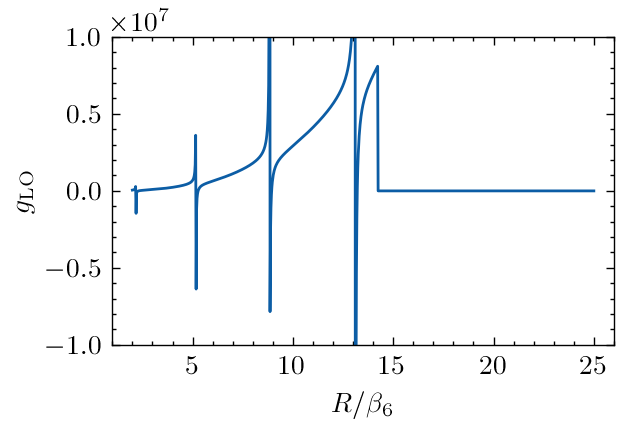

In [4]:
plt.plot(he4.BETA6/R_LO, gsLO)
plt.xlim(1.,26)
plt.ylim(-10000000,10000000)
plt.xlabel('$R/\\beta_6$')
plt.ylabel('$g_{\\rm LO}$')

In [292]:
np.savetxt('rg_flow_lo_nonlocal_2_8_8-physicalC6.txt', np.vstack((R_LO, gsLO)).T, header='R (Å)  g ()')

In [6]:
R_LO, gsLO = np.loadtxt('rg_flow_lo_nonlocal_2_8_8-physicalC6.txt',unpack=True)

# NLO renormalization

In [7]:
# First, we will tune k(cot(delta)). Then we'll go back and refine a_0 and r_0.
def kcd_diff(c_2s, sys, c_00):
    kcd = sys.kcotd_gen_pert1b_fast(momenta, c_00, *c_2s)
    return np.sum(((KCD - kcd)/KCD)**2)

def a0_diff(c_2s, sys, c_00):
    a0, r0 = sys.a0_and_r0_pert1b_fast(c_00, *c_2s, momenta)
    return he4.A0*(1/he4.A0 - 1/a0)

In [17]:
index = 16

print(R_LO[index])
s = he4.NonlocalHelium4System(R_LO[index], ELL, N1, N2, NCT)

2.2703335483775104


In [18]:
s.a0_and_r0(gsLO[index], 0, momenta, use_c=True), s.bound_state_spectrum(gsLO[index], 0)

((np.float64(99.99999240145873), np.float64(7.758898680499639)),
 array([-1.31795213e-03, -6.31581976e+03]))

In [23]:
s = he4.NonlocalHelium4System(R_LO[index], ELL, N1, N2, NCT)
#nlo_guess = result.x
c20 = 1023523.3829002387
test = np.linspace(-50000,-90000,1500)

for i in range(len(test)):
#    result = minimize(lambda x: a0_diff([x,test[i]],s, gsLO[index]),-0.1,tol=1e-6)
    result = optimize.fsolve(lambda x: a0_diff([x,test[i]],s, gsLO[index]), c20,xtol=1e-8)
    c2s = np.array([*result, test[i]])
    atemp, rtemp= s.a0_and_r0_pert1b_fast(gsLO[index], *c2s, momenta)
    print(R_LO[index], gsLO[index],c2s[0],c2s[1],atemp,rtemp)
    c20 = c2s[0]+0.0001*np.abs(c2s[0])

2.2703335483775104 17345.713327977788 1023523.3829002387 -50000.0 100.00036553473943 7.494438118775175
2.2703335483775104 17345.713327977788 1024069.6625769201 -50026.6844563042 100.00008227778576 7.495621059484693
2.2703335483775104 17345.713327977788 1024615.9004225743 -50053.36891260841 100.00003301913334 7.495371381654419
2.2703335483775104 17345.713327977788 1025162.163618979 -50080.05336891261 100.00017061391446 7.495666585147655
2.2703335483775104 17345.713327977788 1025708.3630971839 -50106.73782521681 99.99995765039645 7.494478771520211
2.2703335483775104 17345.713327977788 1026254.604150759 -50133.422281521016 100.00020158038366 7.494032213454532
2.2703335483775104 17345.713327977788 1026800.8529049691 -50160.10673782522 99.99996880635433 7.494276255781951
2.2703335483775104 17345.713327977788 1027347.1139736908 -50186.79119412942 99.99994165750219 7.494668857012597
2.2703335483775104 17345.713327977788 1027893.3754093463 -50213.475650433626 100.00012837186486 7.4948644056189

2.2703335483775104 17345.713327977788 1063945.4356113893 -51974.64976651101 99.99985871667145 7.4858818644827085
2.2703335483775104 17345.713327977788 1064491.663100194 -52001.33422281521 100.00040765737303 7.484741910319849
2.2703335483775104 17345.713327977788 1065037.8726068668 -52028.018679119414 99.99993695142147 7.484095394191194
2.2703335483775104 17345.713327977788 1065584.124965954 -52054.70313542362 99.99990968490755 7.484244051353527
2.2703335483775104 17345.713327977788 1066130.3812186082 -52081.38759172782 100.00004493632999 7.484340624599749
2.2703335483775104 17345.713327977788 1066676.6541725106 -52108.07204803202 100.00016268683858 7.484932648383348
2.2703335483775104 17345.713327977788 1067222.898597378 -52134.75650433623 100.00000523246959 7.4849776678191455
2.2703335483775104 17345.713327977788 1067769.1336590254 -52161.44096064043 99.99982751506386 7.484778023866514
2.2703335483775104 17345.713327977788 1068315.374139863 -52188.12541694463 100.00030289905474 7.4840

2.2703335483775104 17345.713327977788 1103821.1698396648 -53922.61507671781 100.00010710222215 7.474556392013175
2.2703335483775104 17345.713327977788 1104367.4025176172 -53949.299533022015 100.00011016258094 7.474109388906451
2.2703335483775104 17345.713327977788 1104913.6677525078 -53975.98398932622 100.00000637759608 7.474700193578206
2.2703335483775104 17345.713327977788 1105459.9170524515 -54002.66844563042 100.00003758859951 7.474699753032391
2.2703335483775104 17345.713327977788 1106006.1081388055 -54029.352901934624 99.99983455547942 7.473261832535708
2.2703335483775104 17345.713327977788 1106552.3732719035 -54056.03735823883 100.00007547408349 7.473507379550492
2.2703335483775104 17345.713327977788 1107098.6341840269 -54082.72181454303 99.99994449712923 7.473999643551996
2.2703335483775104 17345.713327977788 1107644.881093954 -54109.406270847234 100.00001085315279 7.47389910085524
2.2703335483775104 17345.713327977788 1108191.0623684684 -54136.09072715144 100.00006998508655 7.

2.2703335483775104 17345.713327977788 1143696.9429155695 -55870.580386924616 99.99998707153776 7.464712698242636
2.2703335483775104 17345.713327977788 1144243.1474300404 -55897.26484322882 99.9999226378453 7.463523115157113
2.2703335483775104 17345.713327977788 1144789.42654197 -55923.94929953302 100.00012181031217 7.46421582279035
2.2703335483775104 17345.713327977788 1145335.6253305518 -55950.633755837225 100.0001890515976 7.462729921350479
2.2703335483775104 17345.713327977788 1145881.9444240849 -55977.31821214143 99.99974692301598 7.465199510821676
2.2703335483775104 17345.713327977788 1146428.1861836608 -56004.00266844563 99.99971118376124 7.465047222265479
2.2703335483775104 17345.713327977788 1146974.3917728043 -56030.687124749835 100.00002491515878 7.46351296204461
2.2703335483775104 17345.713327977788 1147520.6705052322 -56057.37158105404 99.99981363708456 7.464597972950613
2.2703335483775104 17345.713327977788 1148066.8830535586 -56084.05603735824 100.00013005852472 7.4632619

2.2703335483775104 17345.713327977788 1183572.751952886 -57818.54569713142 99.99995980726085 7.455806808894498
2.2703335483775104 17345.713327977788 1184118.9748311832 -57845.23015343562 99.99997719823925 7.455062405150047
2.2703335483775104 17345.713327977788 1184665.1701451414 -57871.914609739826 99.99994002493436 7.453577630569554
2.2703335483775104 17345.713327977788 1185211.4714873917 -57898.59906604403 100.0001864956622 7.454861567531795
2.2703335483775104 17345.713327977788 1185757.6356538364 -57925.28352234823 99.99994998014645 7.45268231516589
2.2703335483775104 17345.713327977788 1186303.9165365973 -57951.967978652436 100.00015050985544 7.453422237327808
2.2703335483775104 17345.713327977788 1186850.1791626734 -57978.65243495664 100.00007083487303 7.453915938792542
2.2703335483775104 17345.713327977788 1187396.3924208407 -58005.33689126084 99.99995689435448 7.453023366004156
2.2703335483775104 17345.713327977788 1187942.6976554317 -58032.021347565045 100.00006232541953 7.4545

...

2.2703335483775104 17345.713327977788 1680654.0950176925 -82101.40093395597 100.0000666859159 7.325260631307225
2.2703335483775104 17345.713327977788 1681200.1746127917 -82128.08539026017 99.99732622043038 7.323120236412352
2.2703335483775104 17345.713327977788 1681746.6258227662 -82154.76984656438 99.99986887031773 7.326447840823017
2.2703335483775104 17345.713327977788 1682292.8452305978 -82181.45430286857 99.99968327066203 7.325800208219736
2.2703335483775104 17345.713327977788 1682839.065595945 -82208.13875917278 100.00022412973424 7.324467306077486
2.2703335483775104 17345.713327977788 1683385.4227051672 -82234.82321547698 100.00083787618479 7.3269881851746765
2.2703335483775104 17345.713327977788 1683931.6248315785 -82261.50767178119 99.99975057856912 7.326731836191878
2.2703335483775104 17345.713327977788 1684477.8007000613 -82288.19212808539 100.00090770770124 7.323520225516994
2.2703335483775104 17345.713327977788 1685024.053104551 -82314.8765843896 100.00008084218481 7.324450

2.2703335483775104 17345.713327977788 1721076.1497413896 -84076.05070046698 100.00012754257376 7.316175437753349
2.2703335483775104 17345.713327977788 1721622.3759139362 -84102.73515677117 99.99953647320606 7.316120659462264
2.2703335483775104 17345.713327977788 1722168.5964164624 -84129.41961307538 99.99988640720517 7.314979720589101
2.2703335483775104 17345.713327977788 1722714.7685314107 -84156.1040693796 99.99953292144376 7.313146048658582
2.2703335483775104 17345.713327977788 1723261.145812433 -84182.78852568379 100.00022774888623 7.316165420591693
2.2703335483775104 17345.713327977788 1723807.2997198333 -84209.47298198799 100.0008405229165 7.312849214591432
2.2703335483775104 17345.713327977788 1724353.559789495 -84236.1574382922 100.00013877359794 7.3138842966631685
2.2703335483775104 17345.713327977788 1724899.810652792 -84262.8418945964 100.0000674258798 7.314027093626511
2.2703335483775104 17345.713327977788 1725446.083206578 -84289.52635090059 99.9998228374253 7.314966969615

2.2703335483775104 17345.713327977788 1761498.191256708 -86050.70046697799 99.999207576158 7.307671655342642
2.2703335483775104 17345.713327977788 1762044.3492168996 -86077.3849232822 99.99994060113089 7.304360440405663
2.2703335483775104 17345.713327977788 1762590.653042552 -86104.06937958639 100.00060503143241 7.305300395814741
2.2703335483775104 17345.713327977788 1763136.7463744108 -86130.75383589059 99.99946566367854 7.301978538900053
2.2703335483775104 17345.713327977788 1763683.0578266552 -86157.4382921948 99.9994504544543 7.303806461926596
2.2703335483775104 17345.713327977788 1764229.3820075048 -86184.12274849901 99.99980696297287 7.3056314084712755
2.2703335483775104 17345.713327977788 1764775.61830204 -86210.80720480319 100.00001070975699 7.305091366981135
2.2703335483775104 17345.713327977788 1765321.8694654005 -86237.4916611074 100.0002491160365 7.3049381050940365
2.2703335483775104 17345.713327977788 1765868.063661956 -86264.17611741161 99.99993720233181 7.303696383531503

2.2703335483775104 17345.713327977788 1801920.1016201787 -88025.35023348899 99.99977999008415 7.2939271654191185
2.2703335483775104 17345.713327977788 1802466.3894153626 -88052.03468979319 100.00027896519502 7.294570496049983
2.2703335483775104 17345.713327977788 1803012.5825769703 -88078.7191460974 99.99993476018942 7.293331026330362
2.2703335483775104 17345.713327977788 1803558.8300733475 -88105.40360240161 99.99976394551553 7.293476095144292
2.2703335483775104 17345.713327977788 1804105.045735891 -88132.0880587058 99.99967599257765 7.29263180710848
2.2703335483775104 17345.713327977788 1804651.3525189147 -88158.77251501 100.00002346895471 7.293967413925629
2.2703335483775104 17345.713327977788 1805197.5624424282 -88185.45697131421 100.00046557344412 7.292435508682899
2.2703335483775104 17345.713327977788 1805743.7839075527 -88212.14142761841 99.99953942356049 7.292570641418479
2.2703335483775104 17345.713327977788 1806290.0729373395 -88238.8258839226 100.00018179283134 7.29311639027

2.2703335483775104 17345.713327977788 1842342.0897616001 -90000.0 100.00001445452646 7.28275395827663


## Determine D-wave RG flow

We only consider the LO counterterm in the D-wave.

In [9]:
ELL = 2

# momentum grid
momenta = np.linspace(0.01/he4.BETA6, 1./he4.BETA6, 70)

N1 = 2
N2 = 8
NCT = 8

R_LO, gsLO = np.loadtxt('rg_flow_lo_nonlocal_2_8_8-physicalC6.txt',unpack=True)
data_lm2m2_dwave = np.loadtxt('log_lm2m2_d_200.txt')

In [69]:
index = 34
print(R_LO[index])

1.932233516352946


In [70]:
s = he4.NonlocalHelium4System(R_LO[index], ELL, N1, N2, NCT)

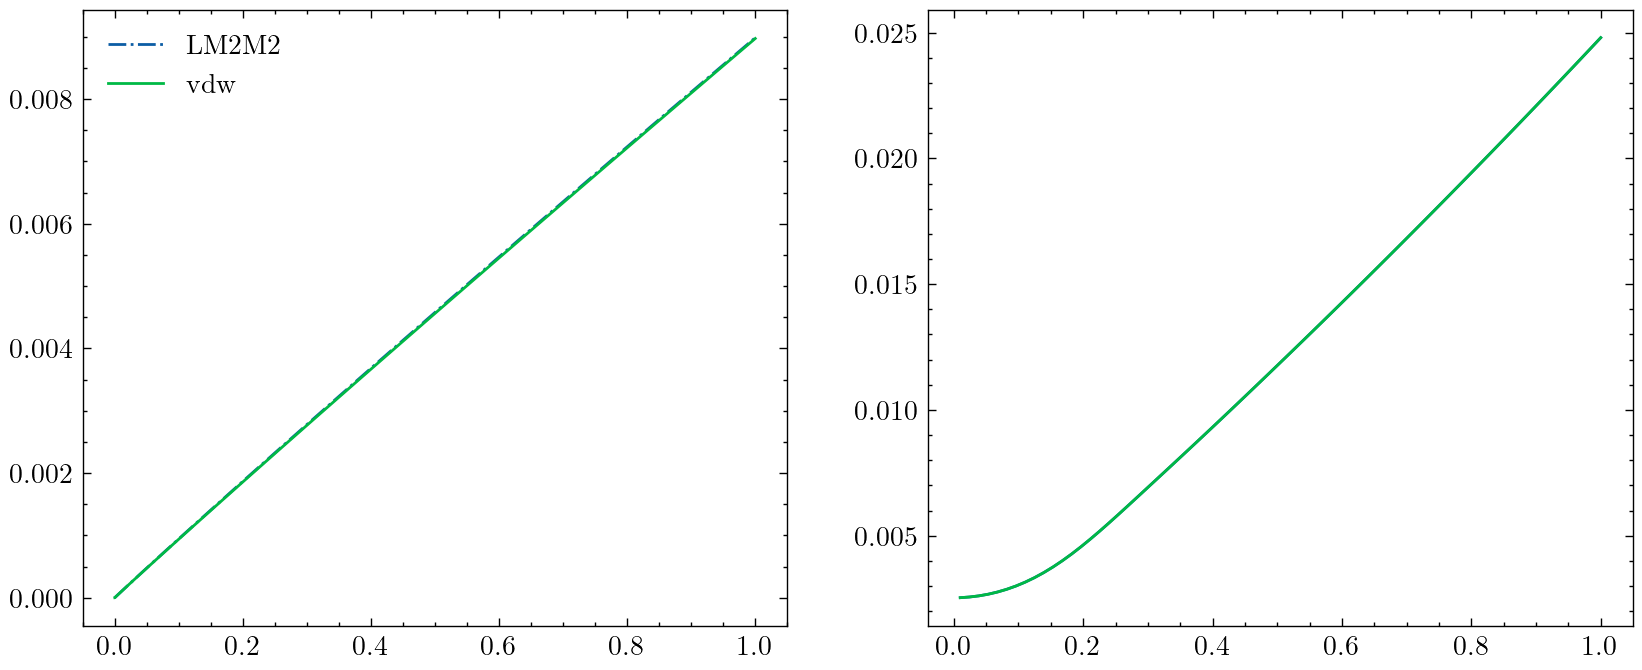

In [76]:
gD = 71.
fig, ax = plt.subplots(1, 2, figsize=(10, 4),dpi=200)
fig.patch.set_facecolor('white')
kcotd = s.kcotd_gen_pert1b_fast(momenta, gD, 0.,0)
kcotd2 = s.kcotd_gen_fast(momenta, gD, 0.)
kcotd3 = s.kcotd_gen(momenta, gD, 0.)
dataD = np.loadtxt('log_lm2m2_d_200.txt')
l = 2
# data = np.loadtxt('log.txt')
k = dataD[:, 0]
lm2m2_D = data_lm2m2_dwave[:, 1]

ax[0].plot((k*he4.BETA6)**4, lm2m2_D, '-.', label='LM2M2')
ax[0].plot((momenta * he4.BETA6)**4, momenta**(2*ELL + 1)/kcotd,label = 'vdw')
#ax[0].plot((momenta * he4.BETA6)**4, momenta**(2*ELL + 1)/kcotd2,'.')
#ax[0].plot((momenta * he4.BETA6)**4, momenta**(2*ELL + 1)/kcotd3,'-')
ax[0].legend()
ax[1].plot(momenta * he4.BETA6, kcotd)
ax[1].plot(momenta * he4.BETA6, kcotd2)

# Writing the data to file

In [7]:
 from pathlib import Path

Read in the RG data stored on disk.

In [8]:
rg_data = np.loadtxt('rg-nlo-reg288.txt')

In [11]:
index = 0
Rtemp = rg_data[index,0]
C00temp = rg_data[index,1]

C01temp = rg_data[index,2]
C02temp = rg_data[index,3]

CDtemp = rg_data[index,4]
    # Generate S-wave interaction
s = he4.NonlocalHelium4System(Rtemp,0, N1, N2, NCT)
v_s_lo = s.v_tilde+s.interaction.counterterm.gen(C00temp,0)
v_s_nlo = s.interaction.counterterm.gen(C01temp,C02temp)
v_s_nlo2 = s.interaction.counterterm.gen(C01temp,0.)+s.interaction.counterterm.gen(0.,C02temp)

In [15]:
rg_data[0,:]

array([ 2.41095564e+00, -6.46324453e+04,  2.31244197e+07, -3.46498541e+05,
        2.60000000e+01,  1.00000000e+02,  7.33004068e+00])

In [12]:
v_s_nlo

array([[23124419.65479935, 23124419.61146653, 23124419.38479616, ...,
               0.        ,        0.        ,        0.        ],
       [23124419.61146653, 23124419.5681337 , 23124419.34146333, ...,
               0.        ,        0.        ,        0.        ],
       [23124419.38479616, 23124419.34146333, 23124419.11479296, ...,
               0.        ,        0.        ,        0.        ],
       ...,
       [       0.        ,        0.        ,        0.        , ...,
               0.        ,        0.        ,        0.        ],
       [       0.        ,        0.        ,        0.        , ...,
               0.        ,        0.        ,        0.        ],
       [       0.        ,        0.        ,        0.        , ...,
               0.        ,        0.        ,        0.        ]])

In [14]:
v_s_nlo - v_s_nlo2

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [110]:
for index in range(len(rg_data)):

    Rtemp = rg_data[index,0]
    C00temp = rg_data[index,1]

    C01temp = rg_data[index,2]
    C02temp = rg_data[index,3]

    CDtemp = rg_data[index,4]
    # Generate S-wave interaction
    s = he4.NonlocalHelium4System(Rtemp,0, N1, N2, NCT)
    v_s_lo = s.v_tilde+s.interaction.counterterm.gen(C00temp,0)
    v_s_nlo = s.interaction.counterterm.gen(C01temp,C02temp)

    # Generate D-wave interaction
    s = he4.NonlocalHelium4System(Rtemp,2, N1, N2, NCT)
    v_d_lo = s.v_tilde+s.interaction.counterterm.gen(CDtemp,0)
    fmt = f"{Rtemp:.5f}".replace('.', 'p')
    fname_swave = Path(f"potential_me_S_R{fmt}.txt")
    fname_dwave = Path(f"potential_me_D_R{fmt}.txt")
    # Assume momenta, weights, and v0_matrix are already defined
    N = len(s.q)
    # Create a list of rows
    rows_swave = []
    rows_dwave = []
    for i in range(N):
        for j in range(N):
            rows_swave.append([s.wq[i], s.q[i], s.q[j], v_s_lo[i, j], v_s_nlo[i,j]])
            rows_dwave.append([s.wq[i], s.q[i], s.q[j], v_d_lo[i,j]])
    # Convert list to a NumPy array
    rows = np.array(rows)
    # Save to file using scientific notation with 8 decimal places.
    # A header is added to match the original file's format.
    np.savetxt(fname_swave, rows_swave, fmt='%.8e',
               header='# weight[i] (1/Å)  momenta[i] (1/Å)  momenta[j] (1/Å)  v_s_lo[i,j] (K•Å^3)  v_s_nlo[i,j] (K•Å^3)')

    np.savetxt(fname_dwave, rows_dwave, fmt='%.8e',
               header='# weight[i] (1/Å)  momenta[i] (1/Å)  momenta[j] (1/Å)  v_d_lo[i,j] (K•Å^3)')

In [104]:
fmt = f"{Rtemp:.5f}".replace('.', 'p')
fname_swave = Path(f"potential_me_S_R{fmt}.txt")
fname_dwave = Path(f"potential_me_D_R{fmt}.txt")

In [105]:
# Assume momenta, weights, and v0_matrix are already defined
N = len(s.q)
# Create a list of rows
rows_swave = []
for i in range(N):
    for j in range(N):
        rows_swave.append([s.wq[i], s.q[i], s.q[j], v_s_lo[i, j], v_s_nlo[i,j]])
        rows_dwave.append([s.wq[i], s.q[i], s.q[j], v_d_lo[i,j]])
# Convert list to a NumPy array
rows = np.array(rows)
# Save to file using scientific notation with 8 decimal places.
# A header is added to match the original file's format.
np.savetxt(fname_swave, rows_swave, fmt='%.8e',
           header='# weight[i] (1/Å)  momenta[i] (1/Å)  momenta[j] (1/Å)  v_s_lo[i,j] (K•Å^3)  v_s_nlo[i,j] (K•Å^3)')

np.savetxt(fname_dwave, rows_dwave, fmt='%.8e',
           header='# weight[i] (1/Å)  momenta[i] (1/Å)  momenta[j] (1/Å)  v_d_lo[i,j] (K•Å^3)')